Loading Pattern C datasets...
Data loading and timestamp alignment complete.
Total missing shockwave cells evaluated: 152

Generating diagnostics for Volume...


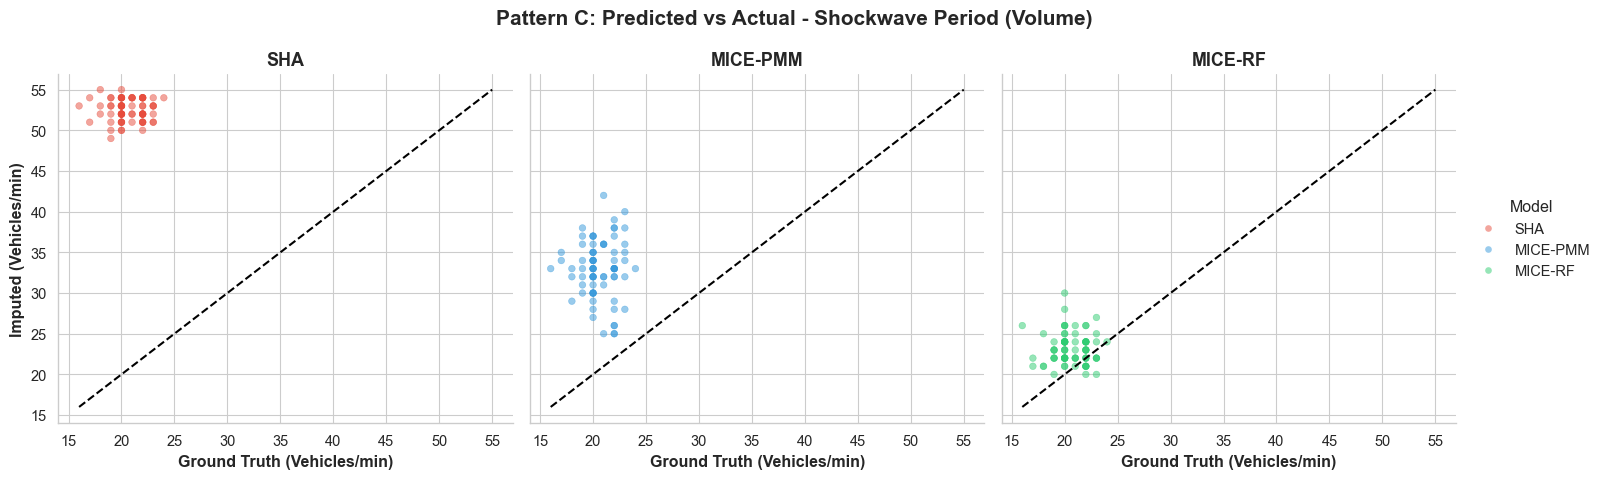

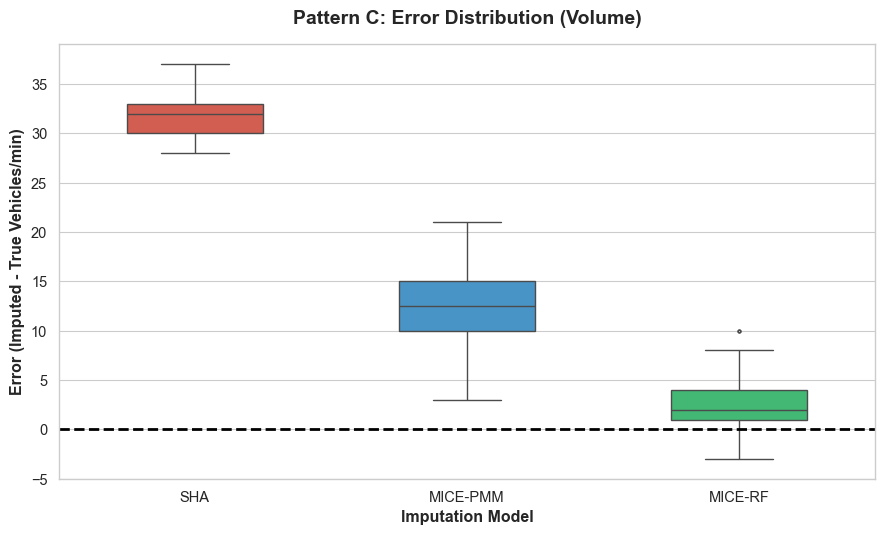

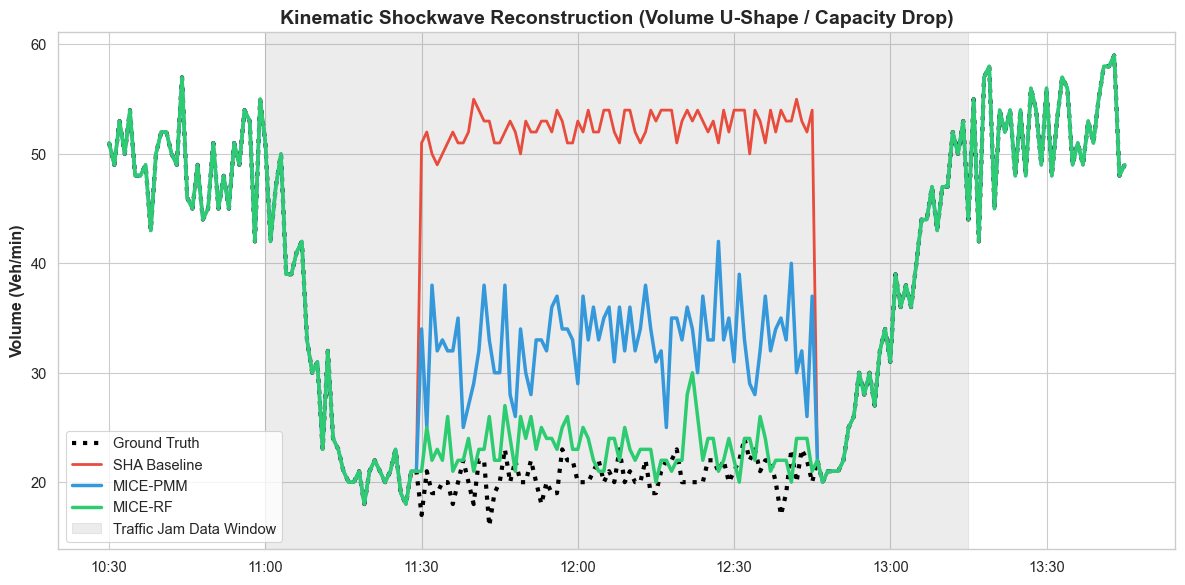

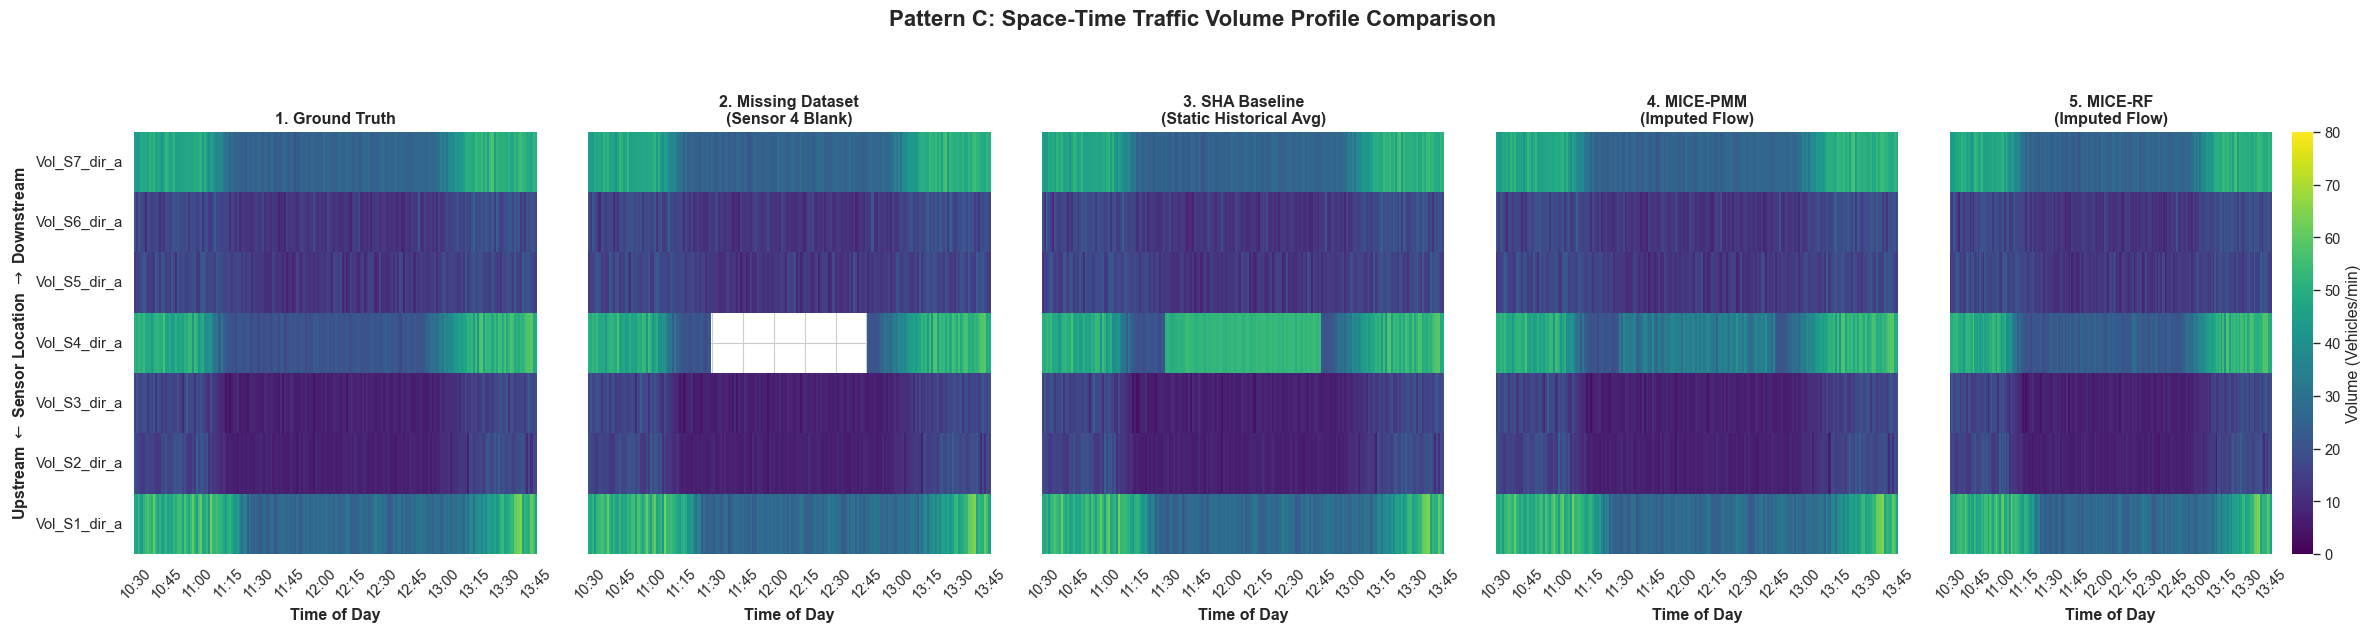


Generating diagnostics for Speed...


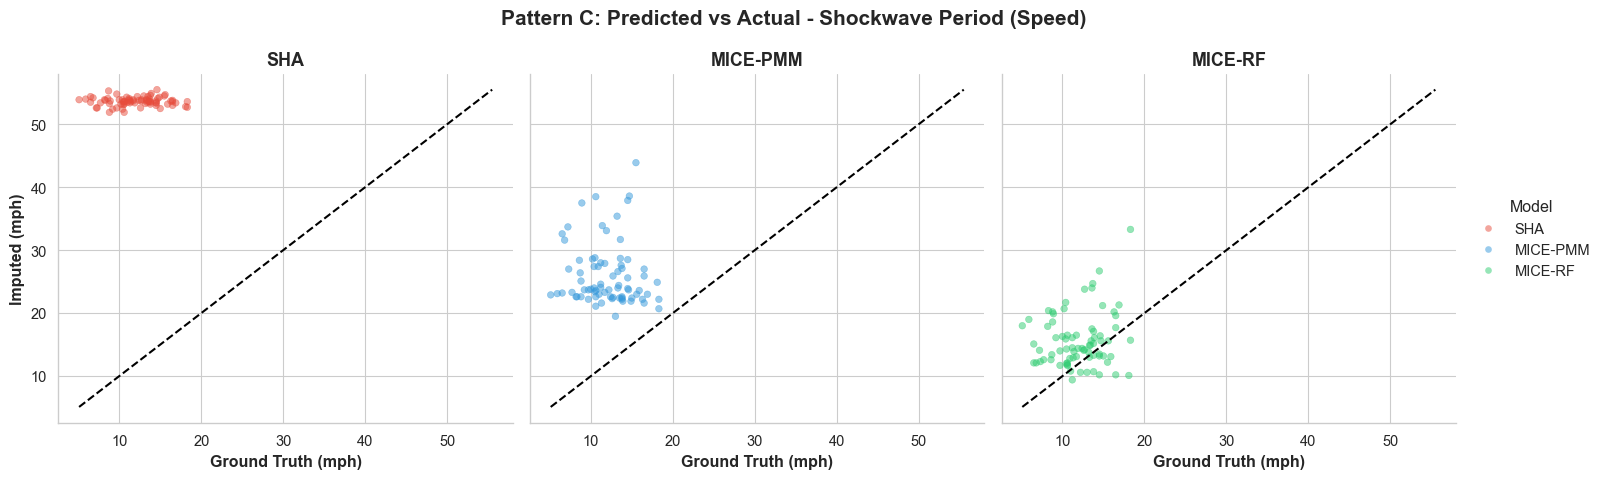

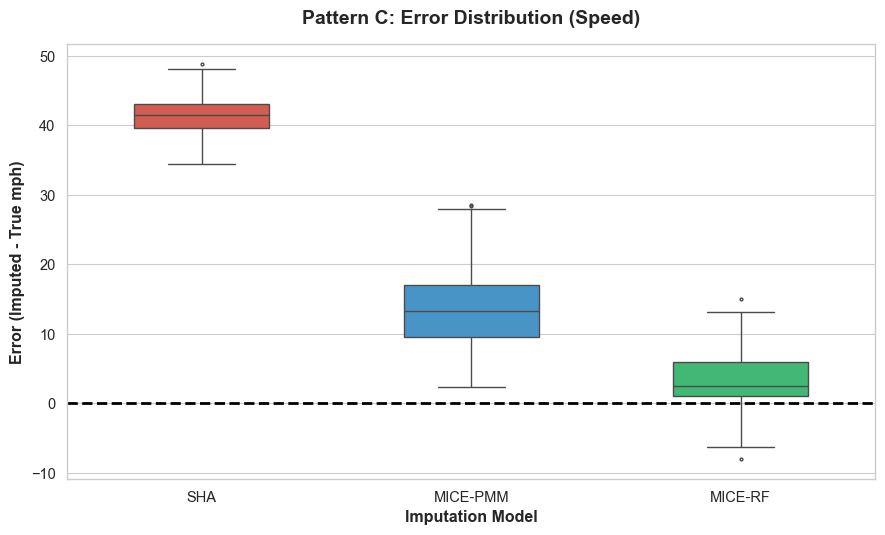

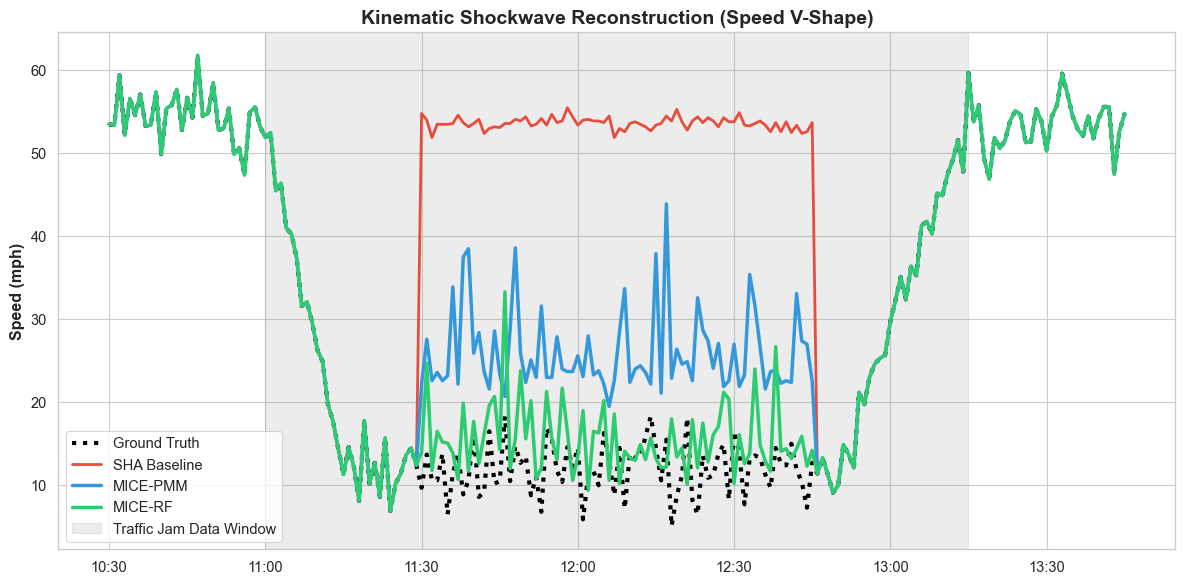

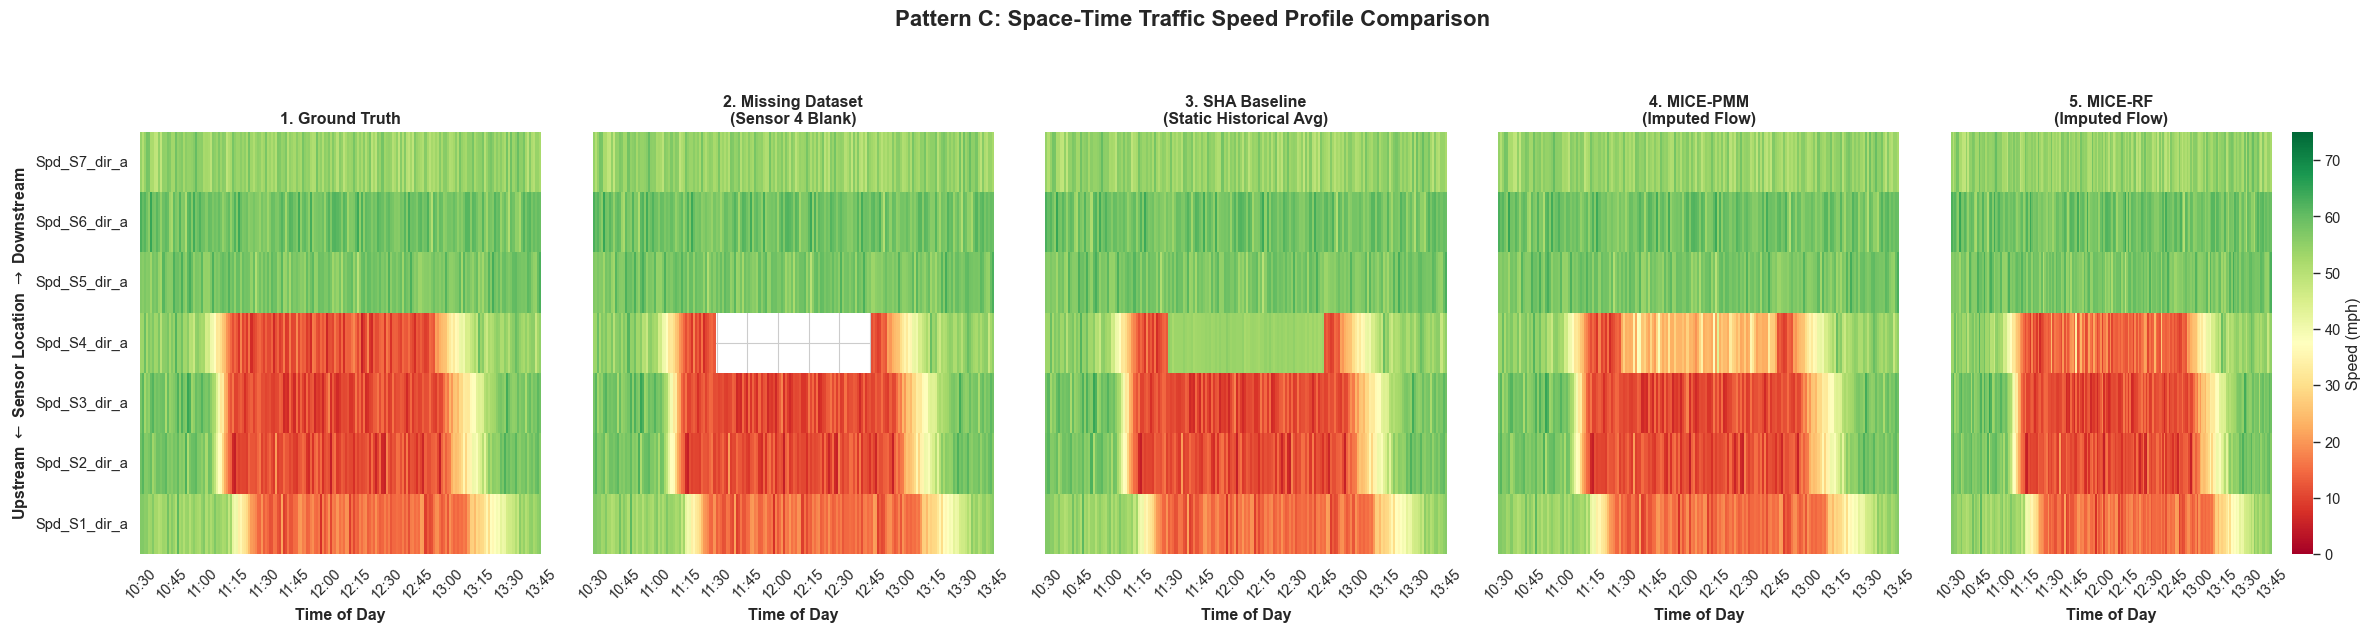


Generating TMT Macroeconomic Plot...


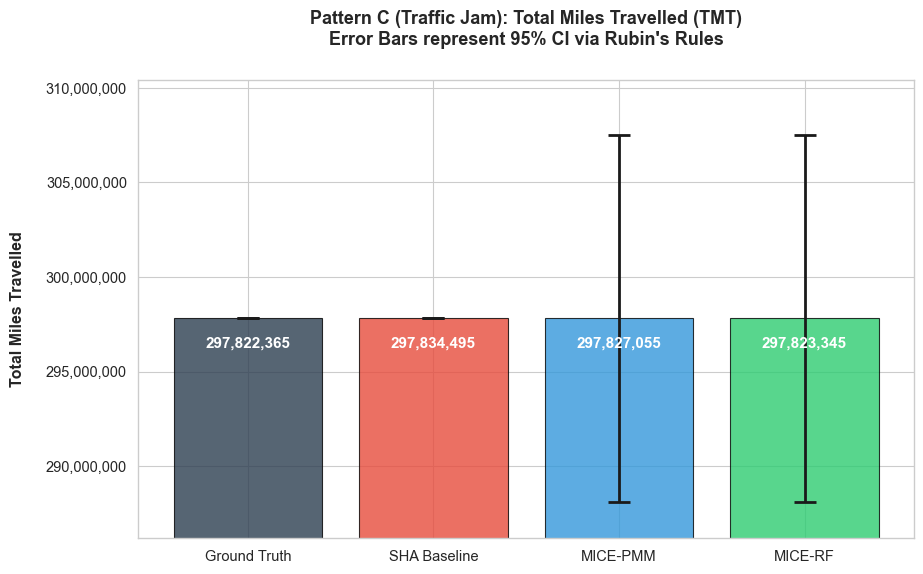


All Pattern C visualizations generated successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import warnings




# 1. GLOBAL SETTINGS 

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = {"SHA": "#e74c3c", "MICE-PMM": "#3498db", "MICE-RF": "#2ecc71"}

# Pattern C Target: Sensor 4 Direction A Shockwave
TARGET_VARS = ['Vol_S4_dir_a', 'Spd_S4_dir_a']
JAM_START = "2026-07-25 11:00:00" 
JAM_END   = "2026-07-25 13:15:00" 


# 2. DATA LOADING & PREPROCESSING

def load_and_prep_data():
    """Loads CSVs and perfectly aligns timestamps across all datasets."""
    print("Loading Pattern C datasets...")
    
    truth_df = pd.read_csv('MICE_wide_1jamnew.csv')
    miss_df  = pd.read_csv('traffic_pattern_c_wide_1jamnew.csv')
    
    models = {
        'SHA': pd.read_csv('traffic_wide_SHA_patternC.csv'),
        'MICE-PMM': pd.read_csv('patternC_MICE_PMM_pooled.csv'),
        'MICE-RF': pd.read_csv('patternC_MICE_RF_pooled.csv')
    }

    tmt_files = {
        'PMM_TMT': pd.read_csv('patternC_TMT.csv'),
        'RF_TMT': pd.read_csv('patternC_MICE_RF_TMT.csv'),
        'SHA_TMT': pd.read_csv('sha_tmt_results_patternC.csv'),
        'PMM_Rubin': pd.read_csv('patternC_Rubin_TMT.csv'),
        'RF_Rubin': pd.read_csv('patternC_MICE_RF_Rubin_TMT.csv')
    }

    # Timestamp Repair Fix
    truth_df['Timestamp'] = pd.to_datetime(truth_df['Timestamp'])
    miss_df['Timestamp']  = pd.to_datetime(truth_df['Timestamp'])

    for name, df in models.items():
        df['Timestamp'] = truth_df['Timestamp'].copy()
        for col in ['DayOfWeek', 'Hour', 'Minute']:
            if col in truth_df.columns:
                df[col] = truth_df[col].copy()

    print("Data loading and timestamp alignment complete.")
    return truth_df, miss_df, models, tmt_files


# 3. DATA WRANGLING FUNCTION

def wrangle_comparison_data(truth_df, miss_df, models):
    """Melts datasets, isolates missing cells, and handles SHA zeroes."""
    truth_melt = truth_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Truth')
    miss_melt = miss_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Missing')

    master_df = truth_melt.merge(miss_melt, on=['Timestamp', 'Variable'])
    mask = master_df['Missing'].isna() & master_df['Truth'].notna()
    
    missing_cases = master_df[mask].copy()
    missing_cases['Hour'] = missing_cases['Timestamp'].dt.hour
    missing_cases['Metric'] = missing_cases['Variable'].apply(lambda x: 'Volume' if 'Vol' in x else 'Speed')

    plot_data = []
    for model_name, imp_df in models.items():
        imp_melt = imp_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Imputed')
        merged = missing_cases.merge(imp_melt, on=['Timestamp', 'Variable'])
        
        merged['Error'] = merged['Imputed'] - merged['Truth']
        merged['Abs_Error'] = merged['Error'].abs()
        merged['Model'] = model_name
        
        if model_name == 'SHA':
            sha_valid = (merged['Imputed'] != 0) & (merged['Imputed'].notna())
            merged = merged[sha_valid]
            
        plot_data.append(merged)

    comparison_df = pd.concat(plot_data, ignore_index=True)
    return comparison_df


# 4. PLOTTING FUNCTIONS

def plot_scatter(df_subset, metric_type, unit):
    g = sns.relplot(
        data=df_subset, x='Truth', y='Imputed', 
        col='Model', hue='Model', palette=PALETTE, 
        alpha=0.5, height=4.5, aspect=1.1, edgecolor=None
    )
    
    max_val = df_subset[['Truth', 'Imputed']].max().max()
    min_val = df_subset[['Truth', 'Imputed']].min().min()
    
    for ax in g.axes.flat:
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5)
        ax.set_title(ax.get_title().replace("Model = ", ""), fontweight='bold', fontsize=13)

    g.set_axis_labels(f"Ground Truth ({unit})", f"Imputed ({unit})", fontweight='bold')
    g.fig.suptitle(f"Pattern C: Predicted vs Actual - Shockwave Period ({metric_type})", y=1.06, fontweight='bold', fontsize=15)
    plt.show()

def plot_error_boxplot(df_subset, metric_type, unit):
    plt.figure(figsize=(9, 5.5))
    ax = sns.boxplot(
        x="Model", y="Error", data=df_subset, 
        hue="Model", palette=PALETTE, legend=False,
        fliersize=2, width=0.5
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=2) 
    
    ax.set_title(f"Pattern C: Error Distribution ({metric_type})", fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(f"Error (Imputed - True {unit})", fontweight='bold')
    ax.set_xlabel("Imputation Model", fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_kinematic_shockwave(truth_df, models, target_var):
    """Plots the U-shape or V-shape kinematic wave reconstruction dynamically."""
    metric_name = "Volume (Veh/min)" if "Vol" in target_var else "Speed (mph)"
    metric_title = "Volume" if "Vol" in target_var else "Speed"
    shape_name = "U-Shape / Capacity Drop" if "Vol" in target_var else "V-Shape"

    view_start = pd.to_datetime(JAM_START) - pd.Timedelta(minutes=30)
    view_end   = pd.to_datetime(JAM_END) + pd.Timedelta(minutes=30)

    # Localize datasets to the time window
    truth_sub = truth_df[(truth_df['Timestamp'] >= view_start) & (truth_df['Timestamp'] <= view_end)].set_index('Timestamp')
    sha_sub   = models['SHA'][(models['SHA']['Timestamp'] >= view_start) & (models['SHA']['Timestamp'] <= view_end)].set_index('Timestamp')
    pmm_sub   = models['MICE-PMM'][(models['MICE-PMM']['Timestamp'] >= view_start) & (models['MICE-PMM']['Timestamp'] <= view_end)].set_index('Timestamp')
    rf_sub    = models['MICE-RF'][(models['MICE-RF']['Timestamp'] >= view_start) & (models['MICE-RF']['Timestamp'] <= view_end)].set_index('Timestamp')

    fig, ax = plt.subplots(figsize=(12, 6))
    sha_valid = (sha_sub[target_var] != 0) & (sha_sub[target_var].notna())

    ax.plot(truth_sub.index, truth_sub[target_var], color="black", linestyle=":", label="Ground Truth", linewidth=3)
    ax.plot(sha_sub.index[sha_valid], sha_sub.loc[sha_valid, target_var], color="#e74c3c", label="SHA Baseline", linewidth=2)
    ax.plot(pmm_sub.index, pmm_sub[target_var], color="#3498db", label="MICE-PMM", linewidth=2.5)
    ax.plot(rf_sub.index, rf_sub[target_var], color="#2ecc71", label="MICE-RF", linewidth=2.5)

    ax.axvspan(pd.to_datetime(JAM_START), pd.to_datetime(JAM_END), color='gray', alpha=0.15, label='Traffic Jam Data Window')

    ax.set_title(f"Kinematic Shockwave Reconstruction ({metric_title} {shape_name})", fontweight='bold', fontsize=14)
    ax.set_ylabel(metric_name, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(loc='lower left', frameon=True)
    plt.tight_layout()
    plt.show()

def plot_propagation_heatmaps(truth_df, miss_df, models, metric_type):
    """Generates Space-Time heatmaps dynamically for Volume or Speed."""
    view_start = pd.to_datetime(JAM_START) - pd.Timedelta(minutes=30)
    view_end   = pd.to_datetime(JAM_END) + pd.Timedelta(minutes=30)
    
    # Configure metric specifics
    prefix = "Vol" if metric_type == "Volume" else "Spd"
    cmap = "viridis" if metric_type == "Volume" else "RdYlGn"
    vmin, vmax = (0, 80) if metric_type == "Volume" else (0, 75)
    cbar_label = 'Volume (Vehicles/min)' if metric_type == "Volume" else 'Speed (mph)'
    sensors = [f'{prefix}_S{i}_dir_a' for i in range(1, 8)]

    # Extract & Localize
    truth_sub = truth_df[(truth_df['Timestamp'] >= view_start) & (truth_df['Timestamp'] <= view_end)].set_index('Timestamp')
    miss_sub  = miss_df[(miss_df['Timestamp'] >= view_start) & (miss_df['Timestamp'] <= view_end)].set_index('Timestamp')
    
    # Transpose and reverse spatial order (Sensor 1 at top)
    matrices = [
        truth_sub[sensors].T.iloc[::-1],
        miss_sub[sensors].T.iloc[::-1],
        models['SHA'][(models['SHA']['Timestamp'] >= view_start) & (models['SHA']['Timestamp'] <= view_end)].set_index('Timestamp')[sensors].T.iloc[::-1],
        models['MICE-PMM'][(models['MICE-PMM']['Timestamp'] >= view_start) & (models['MICE-PMM']['Timestamp'] <= view_end)].set_index('Timestamp')[sensors].T.iloc[::-1],
        models['MICE-RF'][(models['MICE-RF']['Timestamp'] >= view_start) & (models['MICE-RF']['Timestamp'] <= view_end)].set_index('Timestamp')[sensors].T.iloc[::-1]
    ]

    fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharey=True)
    titles = ["1. Ground Truth", "2. Missing Dataset\n(Sensor 4 Blank)", "3. SHA Baseline\n(Static Historical Avg)", "4. MICE-PMM\n(Imputed Flow)", "5. MICE-RF\n(Imputed Flow)"]

    for idx, (mat, ax, title) in enumerate(zip(matrices, axes, titles)):
        is_last = (idx == 4)
        sns.heatmap(mat, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, cbar=is_last, 
                    cbar_kws={'label': cbar_label} if is_last else None, xticklabels=15)
        ax.set_title(title, fontweight='bold')
        
        ax.set_xlabel("Time of Day", fontweight='bold')
        if idx == 0:
            ax.set_ylabel("Upstream $\\leftarrow$ Sensor Location $\\rightarrow$ Downstream", fontweight='bold')
        else:
            ax.set_ylabel("")
            
        labels = [pd.to_datetime(t.get_text()).strftime('%H:%M') for t in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45)

    plt.suptitle(f"Pattern C: Space-Time Traffic {metric_type} Profile Comparison", fontweight='bold', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

def plot_tmt_hero(tmt_files):
    """Plots TMT with dynamic Rubin's Rules Error Bars."""
    tmt_rf  = tmt_files['RF_TMT']
    tmt_pmm = tmt_files['PMM_TMT']
    sha_tmt = tmt_files['SHA_TMT']

    tmt_true = tmt_rf.loc[tmt_rf['Dataset'] == 'GroundTruth', 'TMT'].values[0]
    tmt_sha  = sha_tmt.loc[sha_tmt['Dataset'] == 'SHA_Imputed', 'Total_Miles_Travelled'].values[0]
    tmt_pmm_val = tmt_pmm.loc[tmt_pmm['Dataset'] == 'MICE_PMM_pooled', 'TMT'].values[0]
    tmt_rf_val  = tmt_rf.loc[tmt_rf['Dataset'] == 'MICE_RF_pooled', 'TMT'].values[0]

    se_pmm = tmt_files['PMM_Rubin']['Total_SE'].values[0]
    se_rf  = tmt_files['RF_Rubin']['Total_SE'].values[0]

    fig, ax = plt.subplots(figsize=(10, 6.5)) 
    labels = ['Ground Truth', 'SHA Baseline', 'MICE-PMM', 'MICE-RF']
    values = [tmt_true, tmt_sha, tmt_pmm_val, tmt_rf_val]
    errors = [0, 0, se_pmm * 1.96, se_rf * 1.96] 
    colors = ["#2c3e50", "#e74c3c", "#3498db", "#2ecc71"] 

    bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors, alpha=0.8, 
                  edgecolor='black', error_kw=dict(lw=2, capthick=2))

    # --- DYNAMIC Y-LIMIT FIX INCLUDING ERROR BARS ---
    max_reach = max([val + err for val, err in zip(values, errors)])
    min_reach = min([val - err for val, err in zip(values, errors)])
    total_span = max_reach - min_reach

    # Set limits with 10% padding top and bottom
    ax.set_ylim(min_reach - (total_span * 0.10), max_reach + (total_span * 0.15))

    for bar in bars:
        yval = bar.get_height()
        inside_y_position = yval - (total_span * 0.05)
        ax.text(bar.get_x() + bar.get_width()/2, inside_y_position, 
                f'{int(yval):,}', ha='center', va='top', color='white', fontweight='bold', fontsize=11)

    ax.set_title("Pattern C (Traffic Jam): Total Miles Travelled (TMT)\nError Bars represent 95% CI via Rubin's Rules", 
                 fontweight='bold', pad=25, fontsize=13)
    ax.set_ylabel("Total Miles Travelled", fontweight='bold', labelpad=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    plt.tight_layout(pad=3.0)
    plt.show()


# 5. MAIN EXECUTION

if __name__ == "__main__":
    # 1. Load Data
    truth_df, miss_df, models, tmt_files = load_and_prep_data()

    # 2. Wrangle Data
    comparison_df = wrangle_comparison_data(truth_df, miss_df, models)
    print(f"Total missing shockwave cells evaluated: {len(comparison_df) // 3:,}")

    # 3. Generate Metric-Specific Diagnostics
    metrics_config = [
        {"type": "Volume", "unit": "Vehicles/min", "var": "Vol_S4_dir_a"},
        {"type": "Speed", "unit": "mph", "var": "Spd_S4_dir_a"}
    ]

    for config in metrics_config:
        print(f"\nGenerating diagnostics for {config['type']}...")
        df_subset = comparison_df[comparison_df['Metric'] == config['type']]
        
        # Scatters and Boxplots
        plot_scatter(df_subset, config['type'], config['unit'])
        plot_error_boxplot(df_subset, config['type'], config['unit'])
        
        # Kinematic Reconstructions
        plot_kinematic_shockwave(truth_df, models, config['var'])
        
        # Propagation Heatmaps
        plot_propagation_heatmaps(truth_df, miss_df, models, config['type'])

    # 4. Generate Macro-Economic TMT Plot
    print("\nGenerating TMT Macroeconomic Plot...")
    plot_tmt_hero(tmt_files)
    
    print("\nAll Pattern C visualizations generated successfully.")
    